# 4-A1 作業：自行研發策略

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/4-A1_own_strategy.ipynb)

**對應影片**：第 4 章 作業 4-A1【雲端回測平台 II】自行研發策略！

**和影片的差異**

- 新增的起始筆記本：已經放好下載資料、策略骨架與最佳化流程，直接改 `my_strategy` 就能開始。

在這個作業中，同學們可以自己研發專屬的策略，並把分析結果分享給大家。
不想公開策略的話，只分享績效圖表也可以。

下面先放一個「價格站上長均線就持有」的範例讓程式能完整執行，請改成你自己的想法。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
import numpy as np
import finlab_crypto
from finlab_crypto import Strategy

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '4h')

BTCUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


## 1. 寫出策略

回傳 `entries`（進場）、`exits`（出場），以及想畫在圖上的 `figures`。

In [4]:
@Strategy(period=100)
def my_strategy(ohlcv):
    # TODO: 換成你的策略
    trend = ohlcv.close.rolling(my_strategy.period).mean()
    entries = ohlcv.close > trend
    exits = ohlcv.close < trend

    figures = {'overlaps': {'trend': trend}}
    return entries, exits, figures


portfolio = my_strategy.backtest(ohlcv, freq='4h', plot=True)
portfolio.stats()

Start                          2017-08-17 04:00:00+00:00
End                            2026-09-24 08:00:00+00:00
Period                                3322 days 16:00:00
Start Value                                        100.0
End Value                                     918.837913
Total Return [%]                              818.837913
Benchmark Return [%]                         1819.728091
Max Gross Exposure [%]                             100.0
Total Fees Paid                               627.630252
Max Drawdown [%]                               63.914435
Max Drawdown Duration                 2040 days 16:00:00
Total Trades                                         422
Total Closed Trades                                  421
Total Open Trades                                      1
Open Trade PnL                                 28.837179
Win Rate [%]                                   17.577197
Best Trade [%]                                110.562773
Worst Trade [%]                

## 2. 最佳化參數，並檢查過擬合機率

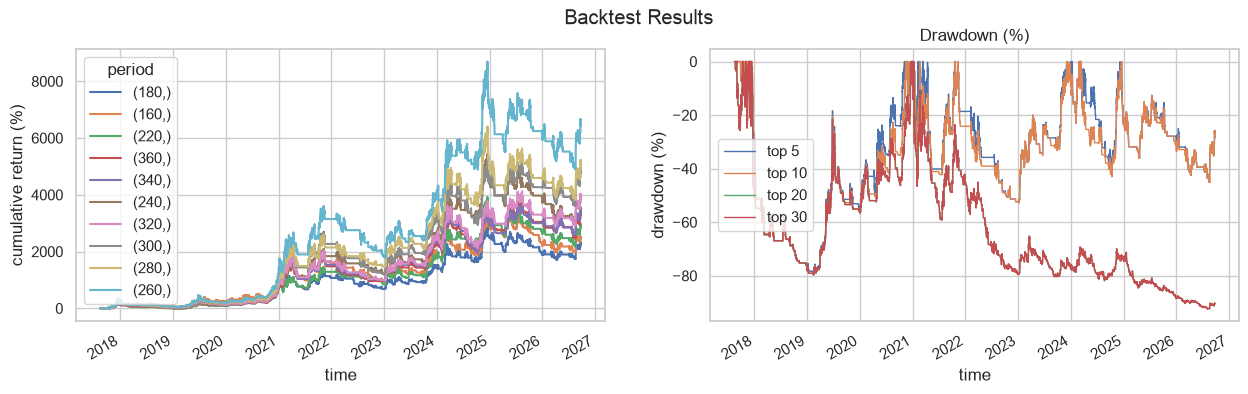

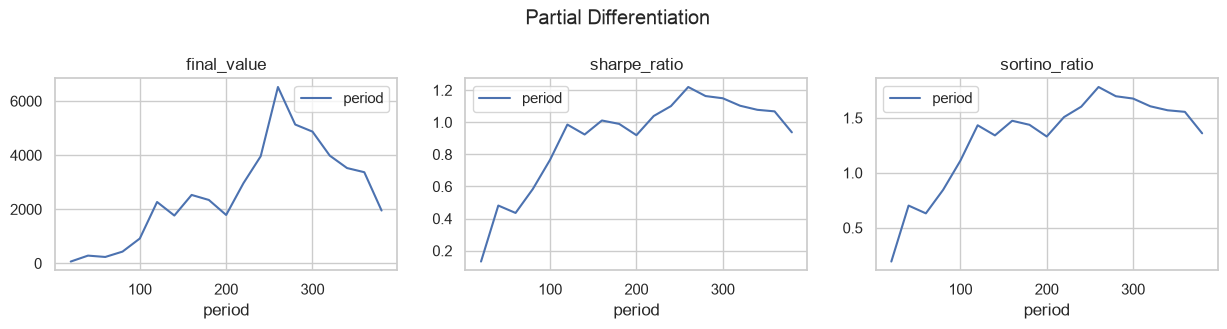

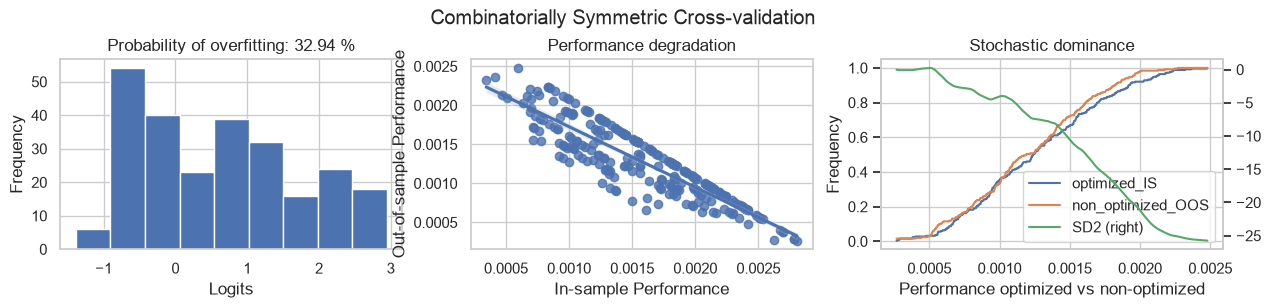

In [5]:
step = 100 if QUICK_RUN else 20
portfolio = my_strategy.backtest(ohlcv, {'period': np.arange(20, 400, step)}, freq='4h', plot=True)

## 3. 分享你的結果

寫下你的策略想法、最佳參數，以及過擬合機率。